# CS194-26: Project 1
### Colorizing the *Prokudin-Gorskii* photo collection

In [1]:
import numpy as np
import skimage as sk
import skimage.io as skio

In [2]:
def horizontal_shift(*, im: np.array, offset: int, fill_color: int = 0, show: bool=True):
    """Shift the input image `im` horizontally by `offset` number of pixels"""
    if not offset:
        return im
    
    width, height = im.shape
    positive_shift = offset > 0
    
    mask = np.full(shape=(width, abs(offset)), fill_value=fill_color)
    spliced_im = im[:, offset:] if positive_shift else im[:, :offset] 
    shifted = [mask, spliced_im] if positive_shift else [spliced_im, mask]
    combined = np.hstack(shifted)
    
    if show:
        skio.imshow(combined)
    return combined

In [3]:
def vertical_shift(*, im: np.array, offset: int, fill_color: int = 0, show: bool=True):
    """Shift the input image `im` vertically by `offset` number of pixels"""
    if not offset:
        return im
    
    width, height = im.shape
    positive_shift = offset > 0
    
    mask = np.full(shape=(abs(offset), height), fill_value=fill_color)
    spliced_im = im[offset:, :] if positive_shift else im[:offset, :] 
    shifted = [spliced_im, mask] if positive_shift else [mask, spliced_im]
    combined = np.vstack(shifted)

    if show:
        skio.imshow(combined)
    return combined

In [4]:
def shift_image(*, im, x_offset: int, y_offset: int, fill_color: int=0, show: bool = False):
    """Shift the input image `im` horizontally and vertically"""
    h_shift = horizontal_shift(im=im, offset=x_offset, fill_color=fill_color, show=show)
    return vertical_shift(im=h_shift, offset=y_offset, fill_color=fill_color, show=show)

In [52]:
def ssd(*, im1, im2, alpha: int = 10):
    """Returns the Sum of Squared Distances between `im1` and `im2`"""
    
    # Make sure arrays have same shape
    assert im1.shape == im2.shape
    x_cut, y_cut = (val // alpha for val in im1.shape)
    im1_reduced = im1[x_cut:-x_cut, y_cut: -y_cut]
    im2_reduced = im2[x_cut:-x_cut, y_cut: -y_cut]
    
    return sum(sum((im1_reduced-im2_reduced)**2))

In [53]:
def align_to_base(*, im: np.array, base_im: np.array, max_displacement=15, loss_f = ssd):
    """Aligns an input image to the base image"""
    optimal_err, optimal_im, optimal_shift = float('inf'), None, None

    for x_disp in range(-max_displacement, max_displacement + 1):
        for y_disp in range(-max_displacement, max_displacement + 1):
            candidate_im = shift_image(im=im, x_offset=x_disp, y_offset=y_disp)
            candidate_error = loss_f(im1=base_im, im2=candidate_im)
            if candidate_error < optimal_err:
                optimal_err = candidate_error
                optimal_im = candidate_im
                optimal_shift = (x_disp, y_disp)

    return optimal_err, optimal_im, optimal_shift

**Cathedral**

In [54]:
def convert_to_bgr_channels(filepath: str):
    """Return three arrays of b, g, r channels"""
    # read in the image
    im = skio.imread(filepath)
    
    # convert to double (might want to do this later on to save memory)    
    im = sk.img_as_float(im)
    
    # compute the height of each part (just 1/3 of total)
    height = np.floor(im.shape[0] / 3.0).astype(int)

    # separate color channels
    b = im[:height]
    g = im[height: 2*height]
    r = im[2*height: 3*height]
    
    return b, g, r

In [55]:
imname = 'data/monastery.jpg'
b, g, r = convert_to_bgr_channels(imname)

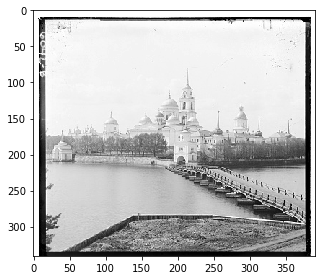

In [56]:
skio.imshow(b);

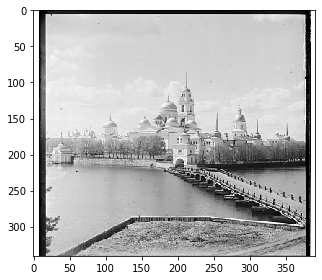

In [57]:
skio.imshow(g);

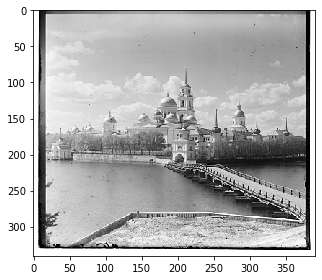

In [58]:
skio.imshow(r);

In [65]:
"text.png".replace(".", "_temp.")

'text_temp.png'

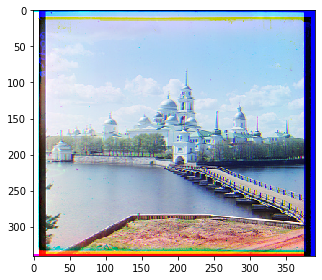

In [60]:
# align the images
# functions that might be useful for aligning the images include:
# np.roll, np.sum, sk.transform.rescale (for multiscale)

_, ag, _ = align_to_base(im=g, base_im=b)
_, ar, _ = align_to_base(im=r, base_im=b)

# create a color image
im_out = np.dstack([ar, ag, b])

# save the image
# fname = '/out_path/out_fname.jpg'
# skio.imsave(fname, im_out)

# display the image
skio.imshow(im_out)
skio.show()